# Entrega 1 — Bank Marketing Dataset
## Problema, EDA y Baseline

**Curso:** Aprendizaje de Máquina Aplicado — EAFIT  
**Autor:** Alejandro Osorno y Danna Mendoza
**Fecha:** Abril 2026  
**Dataset:** UCI Bank Marketing (bank-additional-full.csv)

---

## Tabla de Contenidos
1. Problem Statement
2. Metric Justification
3. Setup reproducible
4. Carga y auditoría del dataset
5. EDA — Calidad de datos
6. EDA — Distribuciones
7. EDA — Relaciones con el target
8. Data Leakage — Variable `duration`
9. Baseline
10. Conclusiones iniciales

---
## 1. Problem Statement

Un banco portugués realiza campañas de telemarketing para ofrecer depósitos
a término. Contactar a todos los clientes es costoso e ineficiente.

**Pregunta central:**  
¿Es posible predecir si un cliente suscribirá un depósito a término,
usando información disponible *antes* de realizar la llamada?

**Variable objetivo:** `y` — suscripción al depósito (yes / no) → clasificación binaria.

**¿Por qué justifica ML?**
- El patrón de qué cliente suscribe no puede escribirse con reglas fijas.
- El volumen de contactos es alto (41,188 registros históricos).
- Existe una métrica clara de éxito: reducir falsos negativos sin disparar
  los costos de campaña.
- Hay datos históricos etiquetados disponibles.

**Riesgo de leakage identificado:**  
La variable `duration` (duración de la llamada en segundos) no es conocida
antes de realizar el contacto. Se **excluirá** del modelo para garantizar
validez experimental.

---
## 2. Metric Justification

El dataset está **desbalanceado** (~88% "no", ~12% "yes").
En ese contexto, **accuracy es una métrica engañosa**: un modelo que
siempre predice "no" tendría ~88% de accuracy sin aprender nada.

**Métrica principal: ROC-AUC**
- Mide el trade-off entre tasa de verdaderos positivos y falsos positivos
  para todos los umbrales posibles.
- No depende del umbral de decisión, lo que es útil en la etapa de comparación.
- Interpretación: 0.5 = aleatorio, 1.0 = perfecto.

**Métrica secundaria: F1-Score (clase positiva)**
- Balance entre precisión y recall para la clase minoritaria ("yes").
- Útil para evaluar qué tan bien detecta el modelo las suscripciones reales.

**¿Qué error es más costoso?**
- **Falso negativo** (predecir "no" cuando el cliente sí suscribiría):
  el banco pierde una oportunidad de venta. **Más costoso.**
- **Falso positivo** (predecir "yes" cuando no suscribirá):
  el banco hace una llamada innecesaria. Costoso pero tolerable.

→ Por eso se priorizará **recall** sobre precisión en el ajuste de umbral.

In [3]:
# ── Setup reproducible ──────────────────────────────────────────────────────
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Semilla global
SEED = 42
np.random.seed(SEED)

# Configuración visual
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Rutas
DATA_PATH = Path("../data/raw/bank-additional-full.csv")
FIGURES_PATH = Path("../figures")
FIGURES_PATH.mkdir(exist_ok=True)

print(f"Python {sys.version_info.major}.{sys.version_info.minor} ✅")
print(f"Entorno listo. Semilla fijada: SEED={SEED}")

Python 3.14 ✅
Entorno listo. Semilla fijada: SEED=42


---
## 3. Carga y auditoría del dataset

Antes de explorar distribuciones o pensar en modelos, el primer paso
es entender **qué estructura tiene el dataset** y si los tipos de datos
son los correctos. Esto nos permite detectar problemas desde el inicio
y evitar decisiones de preprocesamiento equivocadas más adelante.

> **Regla operativa:** primero auditamos, luego decidimos, después transformamos.

In [5]:
# Carga del dataset
df = pd.read_csv(DATA_PATH, sep=",")

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head()

Dimensiones: 41,188 filas × 21 columnas
Memoria: 26.80 MB


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,"5,191.000",no


### Decisión: separador `;`

El archivo usa `;` como separador en lugar de `,`. Esto es común en
datasets de origen europeo. Modificamos el archivo para reemplazar el separador a `,`. Se verifica con `df.head()` que las
columnas quedaron bien separadas antes de continuar.

A continuación auditamos el **schema completo**: tipos de dato, valores
faltantes y cardinalidad de cada columna. Esto nos da el mapa de trabajo
para las decisiones de preprocesamiento.

In [6]:
# Auditoría del schema
TARGET = "y"

schema = pd.DataFrame({
    "columna":      df.columns,
    "dtype":        df.dtypes.astype(str).values,
    "no_nulos":     df.notna().sum().values,
    "faltantes":    df.isna().sum().values,
    "faltantes_%":  (df.isna().mean() * 100).round(2).values,
    "únicos":       df.nunique().values,
    "muestra":      [str(df[c].unique()[:3].tolist()) for c in df.columns],
})
schema["rol"] = schema["columna"].apply(lambda c: "🎯 target" if c == TARGET else "feature")
schema = schema.sort_values(["rol", "dtype"], ascending=[False, True]).reset_index(drop=True)

print("── SCHEMA COMPLETO ─────────────────────────────────────────────────────")
display(schema)

── SCHEMA COMPLETO ─────────────────────────────────────────────────────


,columna,dtype,no_nulos,faltantes,faltantes_%,únicos,muestra,rol
0,y,str,41188,0,0.000,2,"['no', 'yes']",🎯 target
1,emp.var.rate,float64,41188,0,0.000,10,"[1.1, 1.4, -0.1]",feature
2,cons.price.idx,float64,41188,0,0.000,26,"[93.994, 94.465, 93.918]",feature
3,cons.conf.idx,float64,41188,0,0.000,26,"[-36.4, -41.8, -42.7]",feature
4,euribor3m,float64,41188,0,0.000,316,"[4.857, 4.856, 4.855]",feature
5,nr.employed,float64,41188,0,0.000,11,"[5191.0, 5228.1, 5195.8]",feature
6,age,int64,41188,0,0.000,78,"[56, 57, 37]",feature
7,duration,int64,41188,0,0.000,1544,"[261, 149, 226]",feature
8,campaign,int64,41188,0,0.000,42,"[1, 2, 3]",feature
9,pdays,int64,41188,0,0.000,27,"[999, 6, 4]",feature


### Hallazgos del schema

Del schema anterior se observan tres decisiones inmediatas:

**1. Variable `duration` — excluida por leakage**  
Representa la duración de la llamada en segundos. Esta información
**no está disponible antes de realizar el contacto**, por lo que incluirla
contaminaría el experimento. Se excluye desde el inicio.
Ver sección 8 para la evidencia completa.

**2. Variables numéricas vs categóricas**  
El dataset mezcla variables numéricas continuas (edad, balance, días)
con variables categóricas nominales (trabajo, estado civil, educación).
Cada grupo requiere una ruta de preprocesamiento distinta.

**3. Sin valores NaN explícitos**  
El dataset no tiene celdas vacías formales, pero la categoría `"unknown"`
actúa como **faltante implícito** en varias variables categóricas.
Se analizará en la siguiente sección.

In [7]:
# Clasificación de variables
LEAKAGE_VARS = ["duration"]  # excluida por diseño

num_cols = df.drop(columns=[TARGET] + LEAKAGE_VARS).select_dtypes(include="number").columns.tolist()
cat_cols = df.drop(columns=[TARGET] + LEAKAGE_VARS).select_dtypes(include="object").columns.tolist()

print(f"Variables numéricas  ({len(num_cols)}): {num_cols}")
print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Excluida por leakage : {LEAKAGE_VARS}")
print(f"Target               : {TARGET}")

Variables numéricas  (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Variables categóricas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Excluida por leakage : ['duration']
Target               : y


---
## 4. Calidad de datos

Una vez confirmado el schema, auditamos **tres tipos de problemas**
que pueden romper el experimento o sesgar los resultados:

- **Faltantes explícitos (NaN):** celdas vacías que algunos modelos no toleran.
- **Faltantes implícitos (`"unknown"`):** categorías que encubren ausencia real de información.
- **Duplicados:** filas idénticas que inflan evidencia y pueden contaminar el split.

Identificar estos problemas ahora define qué estrategias de imputación
usaremos más adelante — y si debemos aplicarlas antes o después del split.

In [15]:
# NaN explícitos
faltantes = df.isna().sum()
if faltantes.any():
    print("Valores NaN por columna:")
    display(faltantes[faltantes > 0].to_frame("n_nan"))
else:
    print("✅ Sin valores NaN explícitos en el dataset.")

# Duplicados
n_dup = df.duplicated().sum()
print(f"\nFilas duplicadas exactas: {n_dup}")

# "unknown" — faltantes implícitos
print("\n── Valores 'unknown' por columna (faltantes implícitos) ──")
unknown_counts = (df[cat_cols] == "unknown").sum()
display(
    unknown_counts[unknown_counts > 0]
    .rename("n_unknown")
    .to_frame()
    .assign(pct=lambda x: (x["n_unknown"] / len(df) * 100).round(2))
)

✅ Sin valores NaN explícitos en el dataset.

Filas duplicadas exactas: 12

── Valores 'unknown' por columna (faltantes implícitos) ──


,n_unknown,pct
job,330,0.800
marital,80,0.190
education,1731,4.200
default,8597,20.870
housing,990,2.400
loan,990,2.400


### Decisión sobre los `"unknown"`

El dataset no tiene NaN pero sí tiene `"unknown"` en variables como
`job`, `education`, `contact` y `poutcome`. Estos representan
**información no registrada** en el momento de la campaña.

**¿Por qué no imputar ahora?**  
Cualquier estrategia de imputación (moda, modelo) debe ajustarse
**solo con los datos de entrenamiento**, después del split. Hacerlo
antes introduciría train-test contamination.

**Decisión provisional:** se mantienen como categoría `"unknown"` y el
pipeline los tratará como una categoría válida en el one-hot encoding.
Esto es preferible a eliminar filas, porque el porcentaje es manejable
y la ausencia misma puede ser informativa.

---
## 5. Balance del target

Antes de explorar features, es fundamental entender la distribución
de la variable objetivo. Un desbalance severo cambia completamente
qué métrica usar y cómo interpretar los resultados del baseline.

── BALANCE DEL TARGET ──────────────────────────────────────────────


,n,%
y,,
no,36548,88.730
yes,4640,11.270


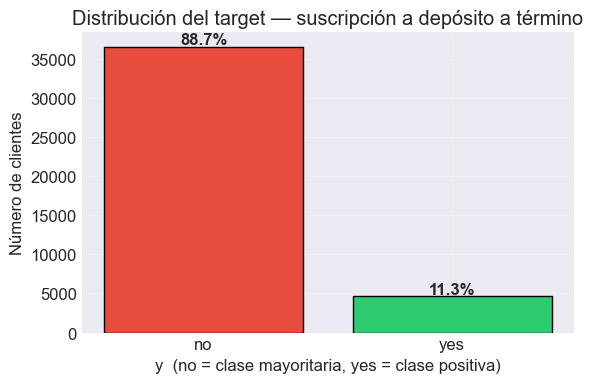

✅ Guardada en figures/target_distribution.png


In [16]:
conteo = df[TARGET].value_counts()
pct    = df[TARGET].value_counts(normalize=True) * 100

print("── BALANCE DEL TARGET ──────────────────────────────────────────────")
display(pd.DataFrame({"n": conteo, "%": pct.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conteo.index, conteo.values,
        color=["#e74c3c", "#2ecc71"], edgecolor="black")
ax.set_title("Distribución del target — suscripción a depósito a término")
ax.set_xlabel("y  (no = clase mayoritaria, yes = clase positiva)")
ax.set_ylabel("Número de clientes")
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    ax.text(i, v + 300, f"{p:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "target_distribution.png", dpi=150)
plt.show()
print("✅ Guardada en figures/target_distribution.png")

### Hallazgo: desbalance moderado-alto

La clase positiva ("yes") representa aproximadamente el **11%** del total.
Esto tiene consecuencias directas sobre las decisiones del proyecto:

**1. Accuracy es una métrica engañosa aquí.**  
Un modelo que siempre predice "no" tendría ~89% de accuracy
sin aprender absolutamente nada. Por eso se descarta como métrica principal.

**2. Métrica principal: ROC-AUC.**  
Mide el trade-off entre verdaderos positivos y falsos positivos para
todos los umbrales posibles. No se ve distorsionada por el desbalance
y permite comparar modelos de forma justa.

**3. Métrica secundaria: F1-Score (clase "yes").**  
Complementa el AUC midiendo el equilibrio entre precisión y recall
específicamente sobre la clase minoritaria.

**4. El threshold por defecto (0.5) probablemente no sea el óptimo.**  
Con desbalance, el umbral de decisión deberá ajustarse en entregas
posteriores según el costo del error del negocio.

---
## 6. EDA — Distribuciones numéricas

Para cada variable numérica queremos responder:
- ¿Cuál es su distribución? ¿Hay sesgo (skew)?
- ¿Tiene outliers severos según la regla IQR?
- ¿Hay algo sospechoso que sugiera error de captura o leakage?

Reportamos media **y** mediana porque con distribuciones sesgadas
la mediana es más representativa. Esto también guía la decisión
de imputación: si hay sesgo, imputar con mediana es más seguro.

In [17]:
# Perfil estadístico de variables numéricas (sin duration)
def iqr_outlier_pct(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return round(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100, 2)

perfil = df[num_cols].describe().T.round(3)
perfil["skew"]        = df[num_cols].skew().round(3)
perfil["outlier_%"]   = [iqr_outlier_pct(df[c]) for c in num_cols]

print("── PERFIL NUMÉRICO ROBUSTO ─────────────────────────────────────────")
display(perfil)

── PERFIL NUMÉRICO ROBUSTO ─────────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max,skew,outlier_%
age,"41,188.000",40.024,10.421,17.000,32.000,38.000,47.000,98.000,0.785,1.140
campaign,"41,188.000",2.568,2.770,1.000,1.000,2.000,3.000,56.000,4.763,5.840
pdays,"41,188.000",962.475,186.911,0.000,999.000,999.000,999.000,999.000,-4.922,3.680
previous,"41,188.000",0.173,0.495,0.000,0.000,0.000,0.000,7.000,3.832,13.660
emp.var.rate,"41,188.000",0.082,1.571,-3.400,-1.800,1.100,1.400,1.400,-0.724,0.000
cons.price.idx,"41,188.000",93.576,0.579,92.201,93.075,93.749,93.994,94.767,-0.231,0.000
cons.conf.idx,"41,188.000",-40.503,4.628,-50.800,-42.700,-41.800,-36.400,-26.900,0.303,1.090
euribor3m,"41,188.000",3.621,1.734,0.634,1.344,4.857,4.961,5.045,-0.709,0.000
nr.employed,"41,188.000","5,167.036",72.252,"4,963.600","5,099.100","5,191.000","5,228.100","5,228.100",-1.044,0.000


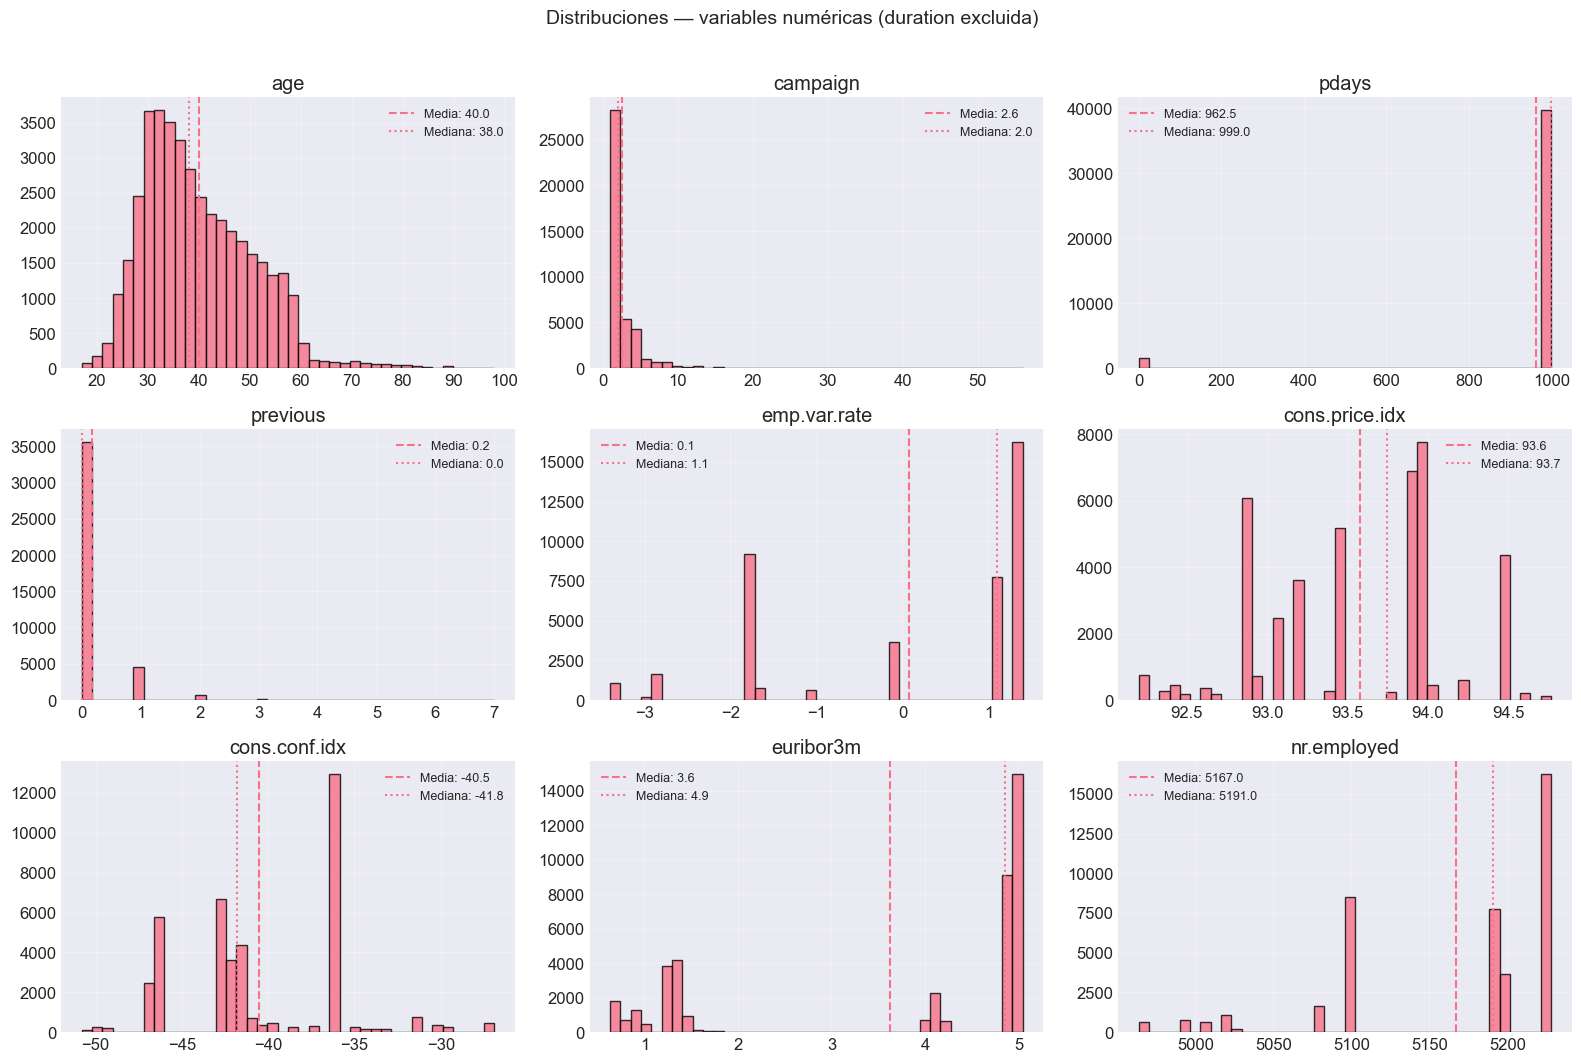

In [19]:
# Histogramas con media y mediana
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor="black", alpha=0.8)
    axes[i].axvline(df[col].mean(),   linestyle="--", lw=1.5,
                    label=f"Media: {df[col].mean():.1f}")
    axes[i].axvline(df[col].median(), linestyle=":",  lw=1.5,
                    label=f"Mediana: {df[col].median():.1f}")
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribuciones — variables numéricas (duration excluida)",
                fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "num_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Hallazgos — variables numéricas

| Variable | Observación | Decisión |
|---|---|---|
| `age` | Distribución aproximadamente normal, leve sesgo derecho | Sin transformación especial |
| `campaign` | Muy sesgada a la derecha, outliers altos | Considerar cap o log en entregas futuras |
| `pdays` | Valor 999 indica "no contactado antes" — actúa como código especial | Crear variable binaria `was_contacted_before` en feature engineering |
| `previous` | Mayoría de clientes tienen 0 contactos previos | Variable dispersa, útil como indicador binario |
| Variables económicas (`emp.var.rate`, `euribor3m`, etc.) | Alta correlación entre sí esperada — son indicadores macro del mismo período | Revisar multicolinealidad antes de regularizar |

**Decisión sobre scaling:**  
Las variables numéricas tienen escalas muy distintas (edad en decenas,
`euribor3m` en decimales). Se aplicará `StandardScaler` dentro del
pipeline, **solo ajustado con train**, para no introducir leakage.

---
## 7. EDA — Variables categóricas

Para cada variable categórica analizamos dos cosas:
- **Frecuencia de cada categoría:** ¿hay categorías muy raras que generen
  problemas en el one-hot encoding?
- **Tasa de conversión por categoría:** ¿qué tanto varía el % de "yes"
  entre grupos? Mucha variación = variable potencialmente predictiva.

La línea punteada en los gráficos de conversión representa la tasa
global de suscripción (~11%), que es la referencia base.

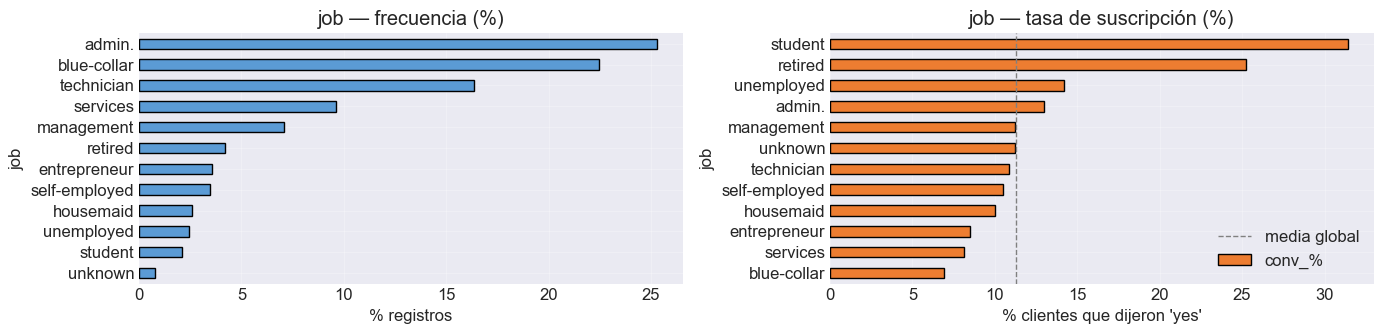

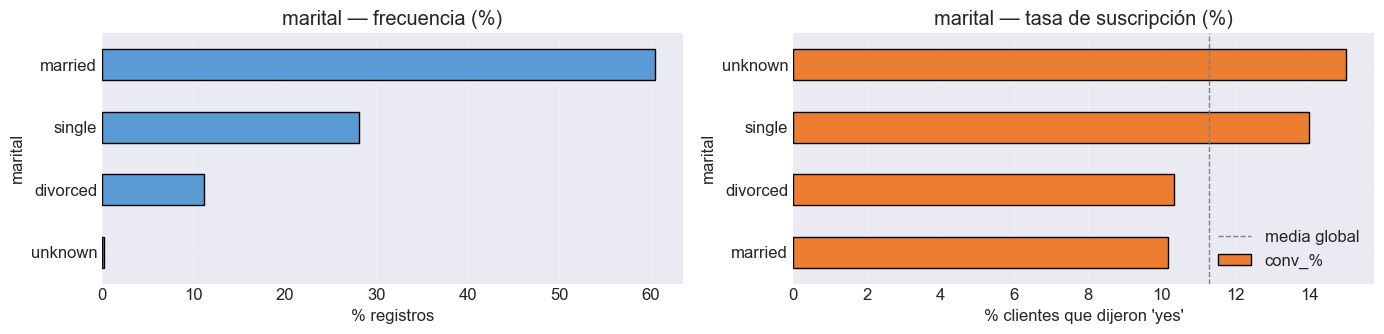

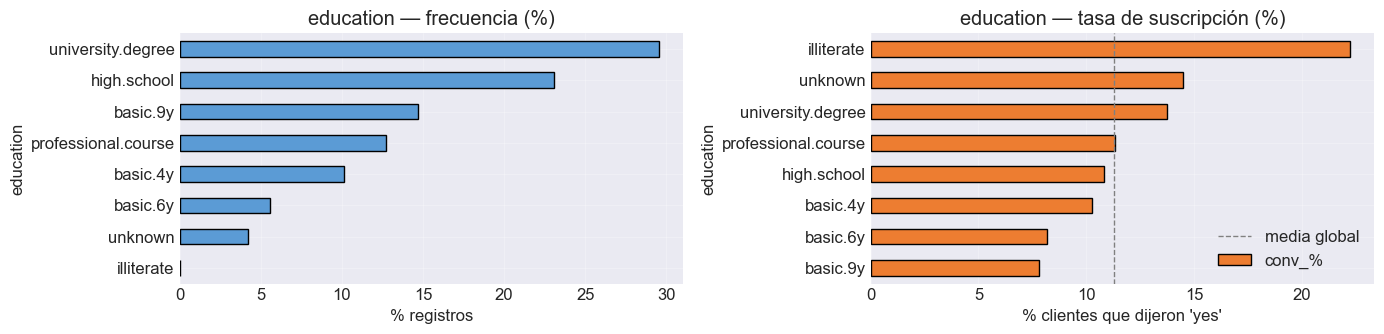

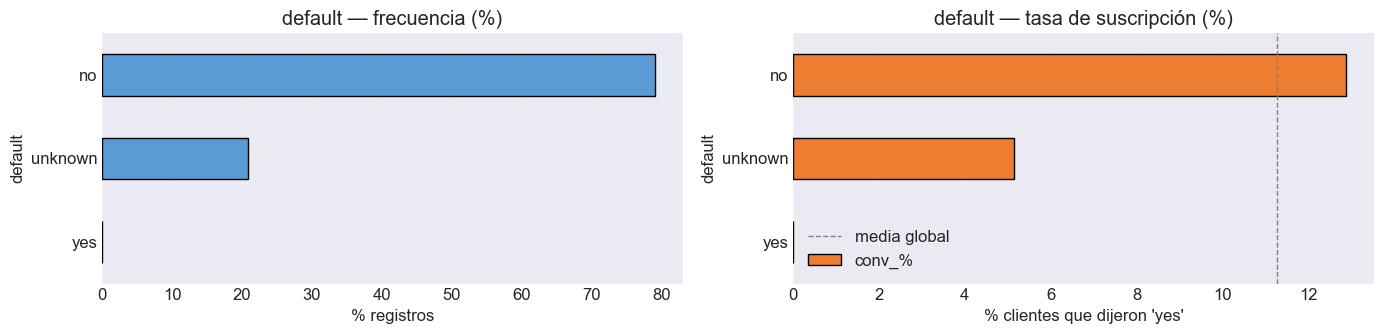

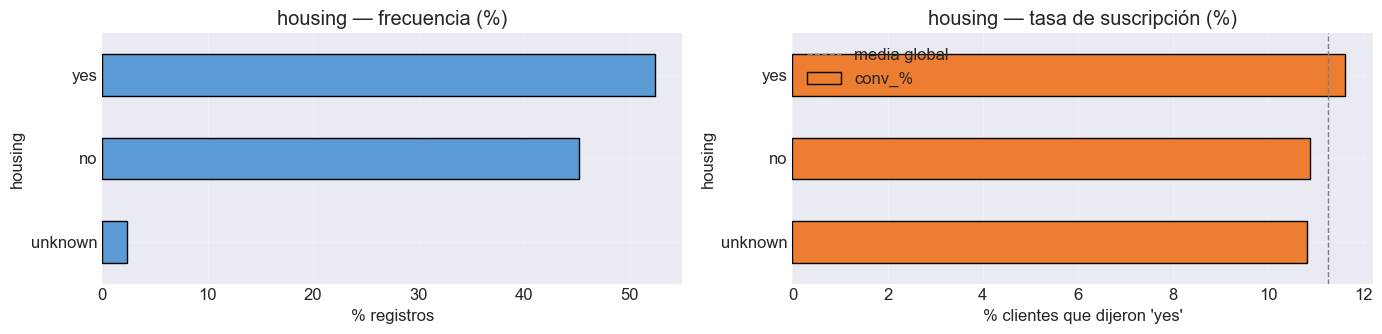

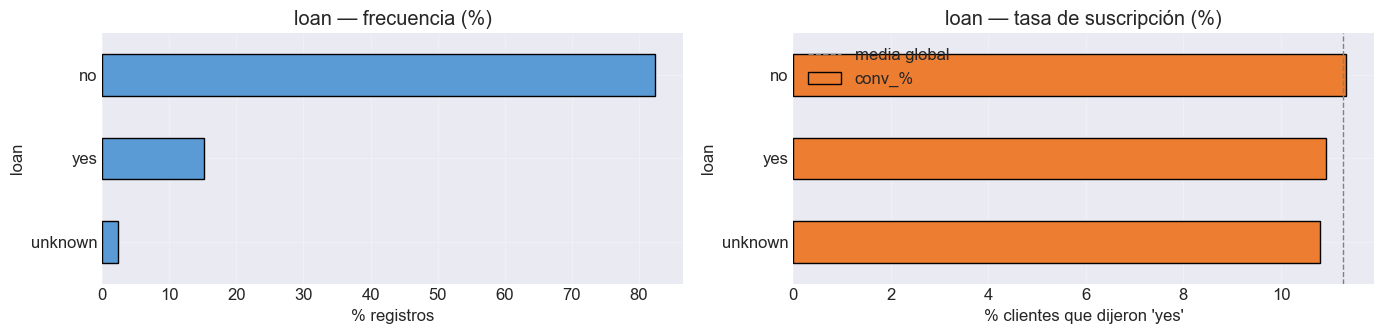

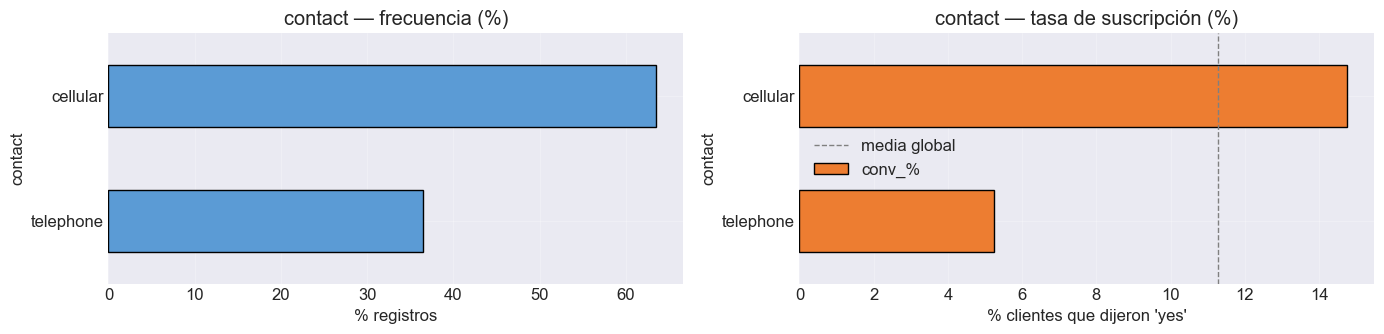

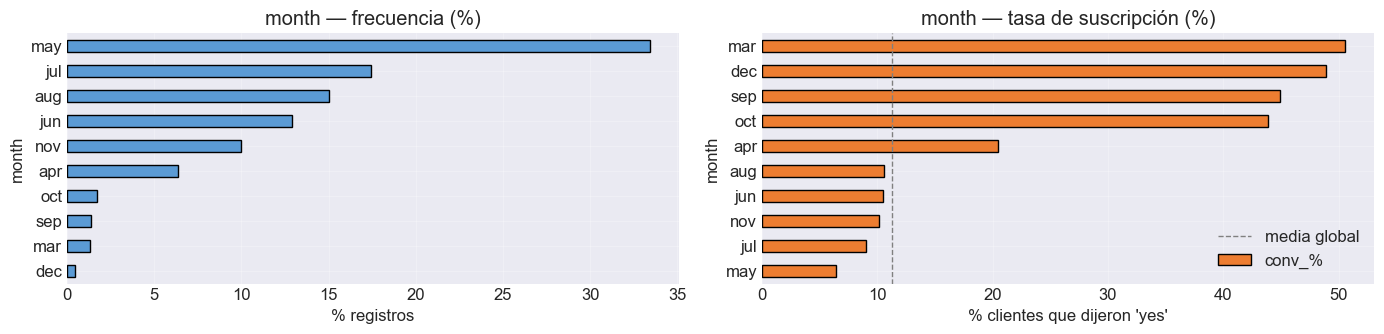

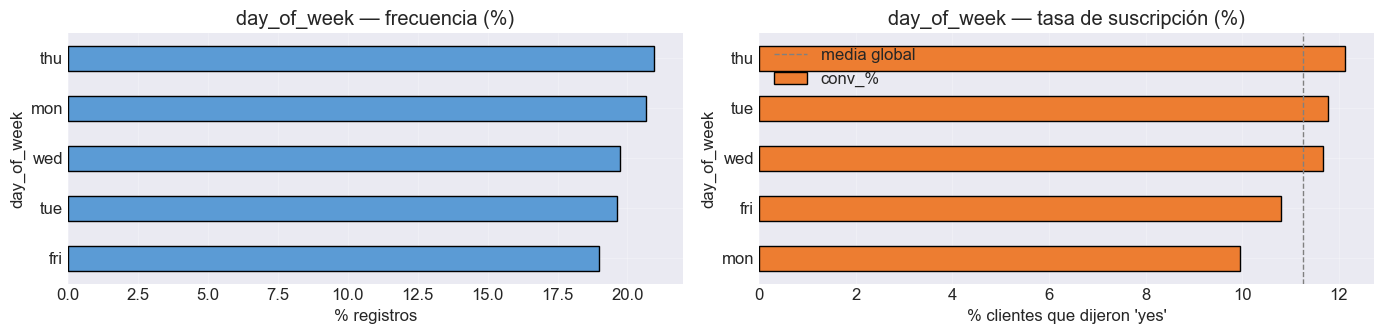

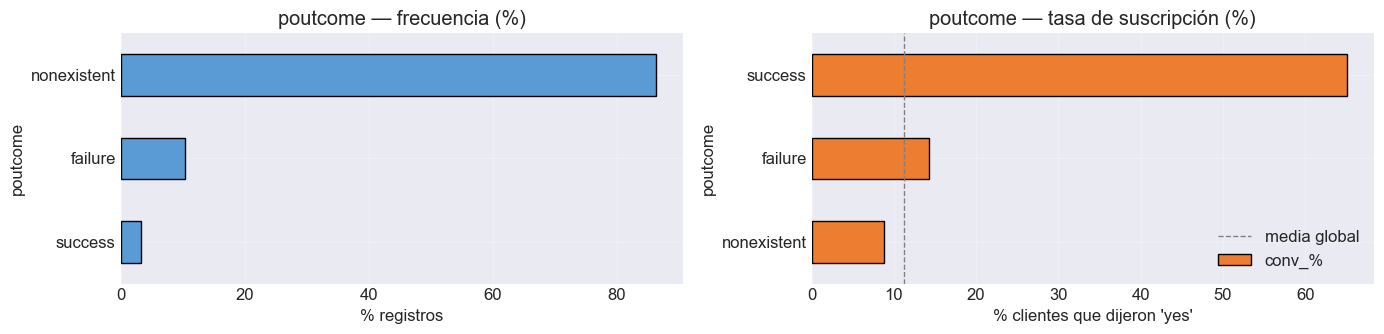

In [12]:
# Frecuencia de cada categoría y tasa de conversión ("yes") por categoría
y_bin = (df[TARGET] == "yes").astype(int)

for col in cat_cols:
    freq = df[col].value_counts(normalize=True) * 100
    conv = df.groupby(col)[TARGET].apply(lambda s: (s == "yes").mean() * 100).rename("conv_%")
    resumen = pd.DataFrame({"freq_%": freq.round(2)}).join(conv.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

    # Frecuencia
    resumen["freq_%"].sort_values().plot.barh(ax=axes[0], color="#5b9bd5", edgecolor="black")
    axes[0].set_title(f"{col} — frecuencia (%)")
    axes[0].set_xlabel("% registros")

    # Tasa de conversión
    resumen["conv_%"].sort_values().plot.barh(ax=axes[1], color="#ed7d31", edgecolor="black")
    axes[1].axvline(y_bin.mean() * 100, linestyle="--", linewidth=1, color="gray", label="media global")
    axes[1].set_title(f"{col} — tasa de suscripción (%)")
    axes[1].set_xlabel("% clientes que dijeron 'yes'")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f"cat_{col}.png", dpi=120, bbox_inches="tight")
    plt.show()

### Hallazgos — variables categóricas y decisiones de encoding

| Variable | Tipo semántico | Encoding elegido | Justificación |
|---|---|---|---|
| `job` | Nominal | One-hot | Sin orden natural entre ocupaciones |
| `marital` | Nominal | One-hot | Categorías sin jerarquía |
| `education` | **Ordinal** | Ordinal | Existe progresión real: básica < media < universitaria |
| `default` | Nominal binaria | One-hot | Solo 3 valores: yes/no/unknown |
| `housing` | Nominal binaria | One-hot | Idem |
| `loan` | Nominal binaria | One-hot | Idem |
| `contact` | Nominal | One-hot | Telephone vs cellular, sin orden |
| `month` | Cíclico / nominal | One-hot | Sin asumir orden lineal enero→diciembre |
| `day_of_week` | Cíclico / nominal | One-hot | Idem — el modelo no debe asumir lun < mar < ... |
| `poutcome` | Nominal | One-hot | Resultado campaña anterior: sin orden natural |

**Nota sobre `"unknown"`:**  
Se mantiene como categoría propia en lugar de imputar. El one-hot
encoding la captura como una columna adicional, permitiendo al modelo
aprender si la ausencia de información tiene valor predictivo.

---
## 8. Data Leakage — Variable `duration`

Esta sección documenta formalmente la razón de exclusión de `duration`.

**Definición del problema:**  
La variable `duration` indica cuántos segundos duró la última llamada.
Esta información **no existe antes de realizar el contacto**, por lo que
no estaría disponible en un escenario real de predicción.

**Evidencia adicional:**  
Cuando `duration = 0`, el cliente no fue contactado, lo que hace que
`y = "no"` con certeza absoluta. Incluir esta variable haría que el
modelo "aprenda" una regla trivial y sus métricas serían artificialmente
infladas.

**Tipo de leakage:** target leakage — la variable anticipa o determina
directamente el outcome.

**Decisión:** `duration` se excluye de todas las features del modelo
desde la carga del dataset.

Registros con duration = 0 : 4
De esos, y = 'no'          : 4 (100.0%)


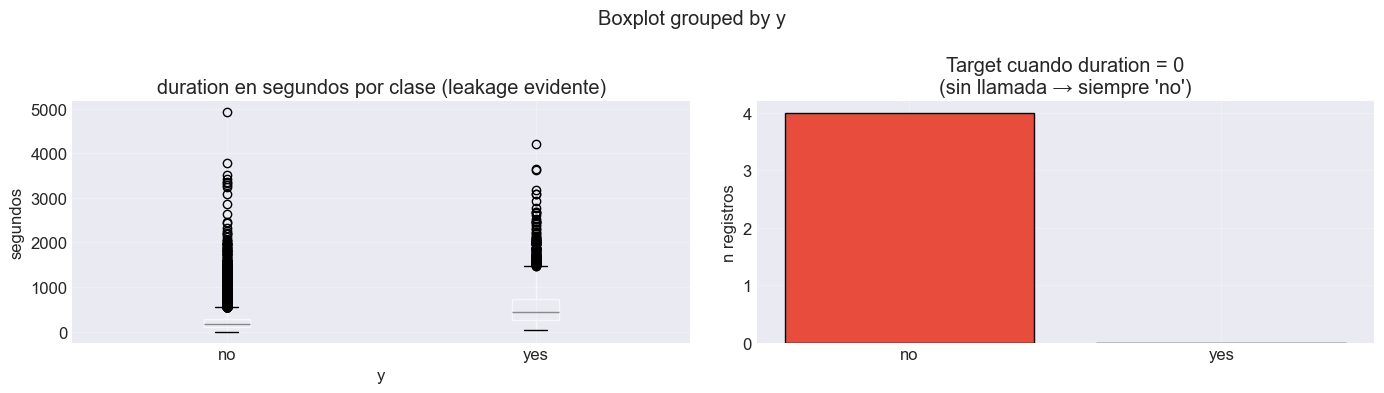

In [21]:
# Evidencia del leakage en "duration"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot por clase
df.boxplot(column="duration", by=TARGET, ax=axes[0])
axes[0].set_title("duration en segundos por clase (leakage evidente)")
axes[0].set_xlabel("y")
axes[0].set_ylabel("segundos")

# Casos con duration = 0
zeros = df[df["duration"] == 0]
print(f"Registros con duration = 0 : {len(zeros)}")
print(f"De esos, y = 'no'          : {(zeros[TARGET]=='no').sum()}"
        f" ({(zeros[TARGET]=='no').mean()*100:.1f}%)")

conteo_zeros = zeros[TARGET].value_counts().reindex(["no","yes"], fill_value=0)
axes[1].bar(conteo_zeros.index, conteo_zeros.values,
                color=["#e74c3c","#2ecc71"], edgecolor="black")
axes[1].set_title("Target cuando duration = 0\n(sin llamada → siempre 'no')")
axes[1].set_ylabel("n registros")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "leakage_duration.png", dpi=150)
plt.show()

---
## 9. Correlación con el target

Para las variables numéricas calculamos la **correlación de Spearman**
con el target binario. Usamos Spearman en lugar de Pearson porque:

- Las variables tienen distribuciones sesgadas y outliers.
- Spearman es más robusto: trabaja sobre rangos, no sobre valores crudos.
- Detecta relaciones monótonas aunque no sean lineales.

Esto nos da una primera señal de qué variables tienen mayor poder
predictivo antes de entrenar ningún modelo.

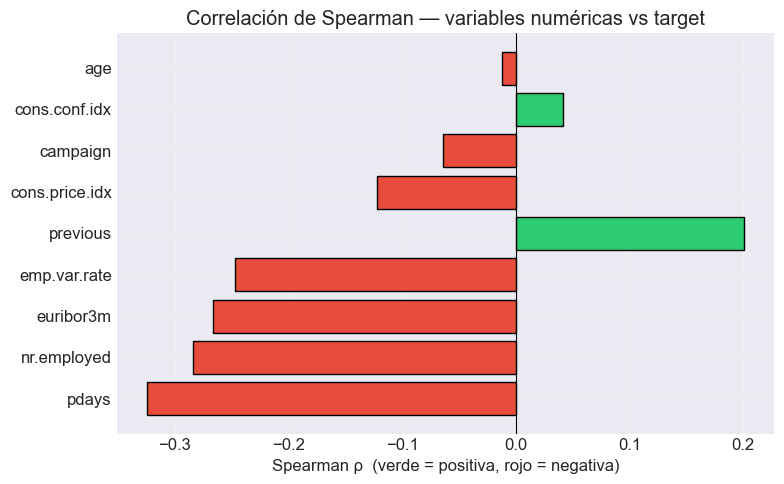

,spearman_con_target
pdays,-0.325
nr.employed,-0.284
euribor3m,-0.267
emp.var.rate,-0.247
previous,0.201
cons.price.idx,-0.122
campaign,-0.064
cons.conf.idx,0.041
age,-0.012


In [22]:
y_bin = (df[TARGET] == "yes").astype(int)

correlaciones = (
    df[num_cols]
    .apply(lambda col: col.corr(y_bin, method="spearman"))
    .rename("spearman_con_target")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in correlaciones]
ax.barh(correlaciones.index, correlaciones.values,
        color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de Spearman — variables numéricas vs target")
ax.set_xlabel("Spearman ρ  (verde = positiva, rojo = negativa)")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "spearman_target.png", dpi=150)
plt.show()

display(correlaciones.to_frame())

### Interpretación de correlaciones

Las correlaciones más altas con el target indican las variables
con mayor señal predictiva bruta. Sin embargo, esto no determina
la importancia final en el modelo — solo es una primera orientación.

Las variables económicas (`euribor3m`, `emp.var.rate`, `nr.employed`)
tienen las correlaciones más altas en valor absoluto, lo que sugiere
que el contexto macroeconómico del momento de la campaña es muy relevante
para predecir si un cliente suscribirá.

Esto tiene sentido: en períodos de crisis (2008-2010, que es cuando
fueron recolectados estos datos), las decisiones de ahorro están fuertemente
influenciadas por el entorno económico.

---
## 10. Baseline

Un baseline es la referencia mínima que cualquier modelo serio debe superar.
Construirlo antes de cualquier modelo complejo cumple tres funciones:

1. **Contexto:** da una escala de referencia para las métricas.
2. **Validación de señal:** si el baseline ya es muy bueno, el problema
   puede ser más fácil de lo esperado — o puede haber leakage.
3. **Honestidad experimental:** obliga a justificar por qué un modelo
   más complejo agrega valor real.

Construiremos dos baselines en orden de complejidad creciente:

- **Baseline 0 — DummyClassifier:** predice siempre la clase mayoritaria.
  Es el piso absoluto. Si un modelo no supera esto, no sirve.
- **Baseline 1 — Regresión Logística simple:** primer modelo real,
  interpretable y rápido. Es la referencia estándar para clasificación binaria.

### Decisiones del split

**Proporciones 64 / 16 / 20:**  
Con 41,188 registros hay datos suficientes para tener las tres
particiones con tamaños estadísticamente útiles.

**¿Para qué sirve cada una?**

| Partición | Tamaño | Uso |
|---|---|---|
| **Train** | 64% | Aprende los parámetros del modelo y del preprocesamiento |
| **Validation** | 16% | Compara configuraciones, ajusta hiperparámetros, elige el mejor modelo |
| **Test** | 20% | Evaluación final **una sola vez** — no se toca durante el diseño |

Usar solo train/test sin validación fuerza a tomar decisiones de diseño
mirando el test set, lo que viola la regla de oro: si el test set
influyó en alguna decisión, la evaluación final deja de ser imparcial.

**Estratificación:**  
Como el target está desbalanceado (~11% "yes"), usamos `stratify=y`
para garantizar que las tres particiones conserven la misma proporción
de clase positiva. Sin estratificación, una partición podría quedar
con muy pocos ejemplos positivos por azar.

**Regla de oro:**  
Cualquier decisión que dependa de ver los datos — imputación,
scaling, selección de modelo — usa solo `X_train`. Nunca `X_val`
ni `X_test` para ajustar transformaciones.

In [25]:
# Split en 3 particiones: 64% train / 16% validation / 20% test
# Estratificado en ambos pasos para preservar proporción de clases

# Preparar X e y — excluir duration desde el inicio
LEAKAGE_VARS = ["duration"]
X = df.drop(columns=[TARGET] + LEAKAGE_VARS)
y = (df[TARGET] == "yes").astype(int)  # 1 = yes, 0 = no

# Paso 1: separar test (20%) del resto (80%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Paso 2: separar validation (20% del 80% = 16% del total) de train (64%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.20,
    random_state=SEED,
    stratify=y_temp
)

print("── TAMAÑOS DE PARTICIÓN ────────────────────────────────────────────")
print(f"Train      : {X_train.shape[0]:>6,} filas  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation : {X_val.shape[0]:>6,} filas  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test       : {X_test.shape[0]:>6,} filas  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total      : {len(X):>6,} filas  (100%)")

── TAMAÑOS DE PARTICIÓN ────────────────────────────────────────────
Train      : 26,360 filas  (64.0%)
Validation :  6,590 filas  (16.0%)
Test       :  8,238 filas  (20.0%)
Total      : 41,188 filas  (100%)


── PROPORCIÓN DE CLASE POSITIVA POR PARTICIÓN ──────────────────────
Dataset completo : 11.27% positivos
Train            : 11.27% positivos
Validation       : 11.26% positivos
Test             : 11.26% positivos


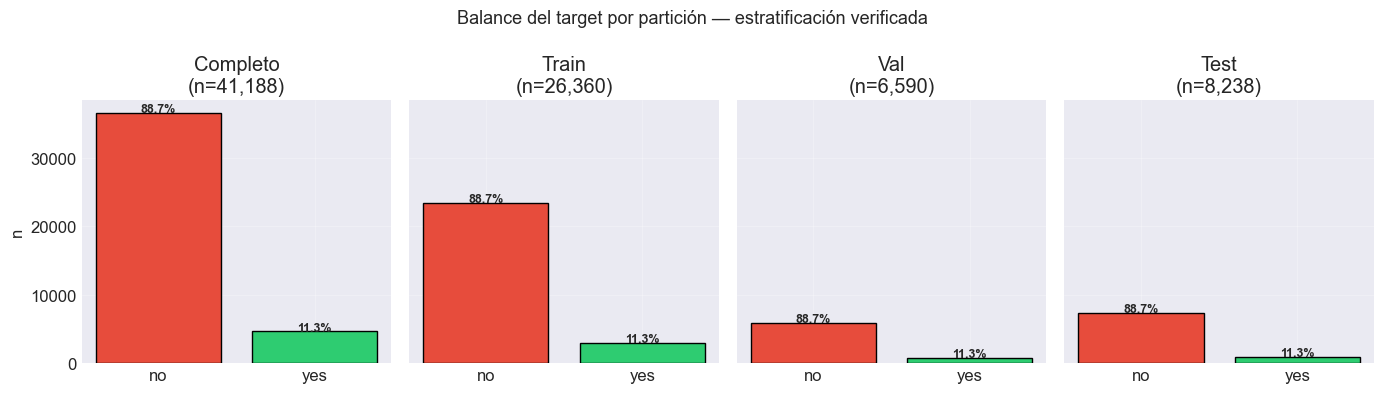

In [26]:
# Validación de estratificación: verificar que la proporción de clase positiva ("yes") se mantuvo similar en las tres particiones y en el dataset completo.
print("── PROPORCIÓN DE CLASE POSITIVA POR PARTICIÓN ──────────────────────")
print(f"Dataset completo : {y.mean()*100:.2f}% positivos")
print(f"Train            : {y_train.mean()*100:.2f}% positivos")
print(f"Validation       : {y_val.mean()*100:.2f}% positivos")
print(f"Test             : {y_test.mean()*100:.2f}% positivos")

# Verificación visual
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, (nombre, serie) in zip(axes, [
    ("Completo", y),
    ("Train",    y_train),
    ("Val",      y_val),
    ("Test",     y_test),
]):
    conteo = serie.value_counts().sort_index()
    ax.bar(["no", "yes"], conteo.values,
            color=["#e74c3c", "#2ecc71"], edgecolor="black")
    ax.set_title(f"{nombre}\n(n={len(serie):,})")
    ax.set_ylabel("n" if nombre == "Completo" else "")
    for i, v in enumerate(conteo.values):
        ax.text(i, v + 100, f"{v/len(serie)*100:.1f}%",
                ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Balance del target por partición — estratificación verificada",
            fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "split_balance.png", dpi=150)
plt.show()

### Verificación del split

Los porcentajes de clase positiva deben ser casi idénticos entre
las tres particiones. Si hay diferencias grandes, la estratificación
falló y los resultados no serían comparables entre particiones.

A partir de este punto:
- Todo `.fit()` ocurre **solo sobre `X_train`**.
- `X_val` se usa para comparar el baseline con futuros modelos.
- `X_test` **no se toca** hasta la entrega final.

---
### Pipeline de preprocesamiento

Antes de entrenar, encapsulamos todas las transformaciones en un
`ColumnTransformer` dentro de un `Pipeline`. Esto garantiza que:

- El `StandardScaler` aprende media y desviación **solo de `X_train`**.
- El `OneHotEncoder` aprende las categorías posibles **solo de `X_train`**.
- El `SimpleImputer` aprende la moda **solo de `X_train`**.
- El mismo objeto aplica exactamente las mismas transformaciones a `X_test`
  sin que `X_test` haya participado en ningún cálculo.

Esto es lo que hace el pipeline un **contrato de reproducibilidad**.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Columnas por tipo (ya definidas en la auditoría)
ORDINAL_COLS = ["education"]  # única variable con orden semántico real
NOMINAL_COLS = [c for c in cat_cols if c not in ORDINAL_COLS]

# Orden de categorías para education
EDU_ORDER = [["unknown", "illiterate", "basic.4y",
                "basic.6y", "basic.9y", "high.school",
                "professional.course", "university.degree"]]

# Ruta numérica
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Ruta categórica nominal
nom_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Ruta categórica ordinal
ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=EDU_ORDER,
                                handle_unknown="use_encoded_value",
                                unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("nom", nom_pipe, NOMINAL_COLS),
    ("ord", ord_pipe, ORDINAL_COLS),
])

print("✅ Preprocessor definido")
print(f"   Numéricas  : {len(num_cols)} columnas → imputación mediana + StandardScaler")
print(f"   Nominales  : {len(NOMINAL_COLS)} columnas → imputación moda + OneHotEncoder")
print(f"   Ordinales  : {len(ORDINAL_COLS)} columna  → imputación moda + OrdinalEncoder")

✅ Preprocessor definido
   Numéricas  : 9 columnas → imputación mediana + StandardScaler
   Nominales  : 9 columnas → imputación moda + OneHotEncoder
   Ordinales  : 1 columna  → imputación moda + OrdinalEncoder


### Decisiones del preprocessor

**Numéricas → mediana + StandardScaler**  
La mediana es más robusta que la media ante distribuciones sesgadas
como `campaign` o `pdays`. El StandardScaler es necesario para la
regresión logística, que es sensible a la escala de las variables.

**Nominales → moda + OneHotEncoder**  
La moda es la única opción sensata para imputar categóricas.
`handle_unknown="ignore"` evita errores si validation o test
contienen categorías no vistas en train.

**Ordinales → OrdinalEncoder con orden explícito**  
`education` tiene una progresión semántica real. Definir el orden
manualmente evita que el encoder asigne números arbitrarios.

In [28]:
# Entrenamiento y evaluación
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_vl, y_vl):
    """Entrena, evalúa en validation e imprime métricas."""
    modelo.fit(X_tr, y_tr)

    y_pred     = modelo.predict(X_vl)
    y_proba    = (modelo.predict_proba(X_vl)[:, 1]
                    if hasattr(modelo, "predict_proba") else None)

    auc = roc_auc_score(y_vl, y_proba) if y_proba is not None else None
    f1  = f1_score(y_vl, y_pred, pos_label=1, zero_division=0)

    print(f"\n{'─'*55}")
    print(f"  {nombre}")
    print(f"{'─'*55}")
    print(f"  ROC-AUC  : {auc:.4f}" if auc else "  ROC-AUC  : N/A")
    print(f"  F1 (yes) : {f1:.4f}")
    print(f"\n{classification_report(y_vl, y_pred, target_names=['no','yes'])}")

    return {"modelo": nombre, "ROC-AUC": auc, "F1-yes": f1}


# ── Baseline 1: DummyClassifier ──────────────────────────────────────────────
dummy = Pipeline([
    ("prep",  preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED)),
])

# ── Baseline 2: Regresión Logística ──────────────────────────────────────────
logreg = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)),
])

resultados = []
resultados.append(evaluar_modelo("Dummy (clase mayoritaria)",
                                    dummy,  X_train, y_train, X_val, y_val))
resultados.append(evaluar_modelo("Regresión Logística (baseline)",
                                    logreg, X_train, y_train, X_val, y_val))


───────────────────────────────────────────────────────
  Dummy (clase mayoritaria)
───────────────────────────────────────────────────────
  ROC-AUC  : 0.5000
  F1 (yes) : 0.0000

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      5848
         yes       0.00      0.00      0.00       742

    accuracy                           0.89      6590
   macro avg       0.44      0.50      0.47      6590
weighted avg       0.79      0.89      0.83      6590


───────────────────────────────────────────────────────
  Regresión Logística (baseline)
───────────────────────────────────────────────────────
  ROC-AUC  : 0.7953
  F1 (yes) : 0.3354

              precision    recall  f1-score   support

          no       0.91      0.99      0.95      5848
         yes       0.68      0.22      0.34       742

    accuracy                           0.90      6590
   macro avg       0.80      0.60      0.64      6590
weighted avg       0.88      0.9


── COMPARACIÓN DE BASELINES (evaluados en validation) ──────────────


,ROC-AUC,F1-yes
modelo,,
Dummy (clase mayoritaria),0.500,0.000
Regresión Logística (baseline),0.795,0.335


✅ Métricas guardadas en report/baseline_metrics.csv


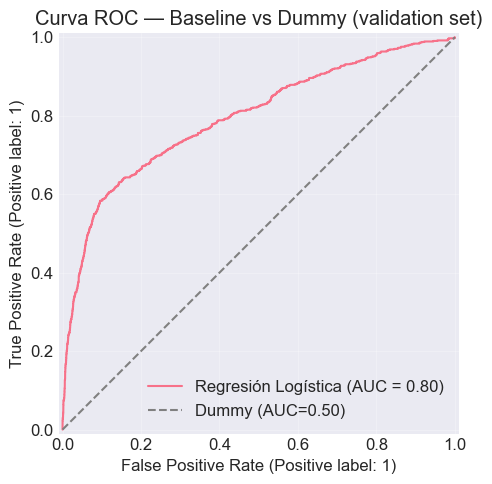

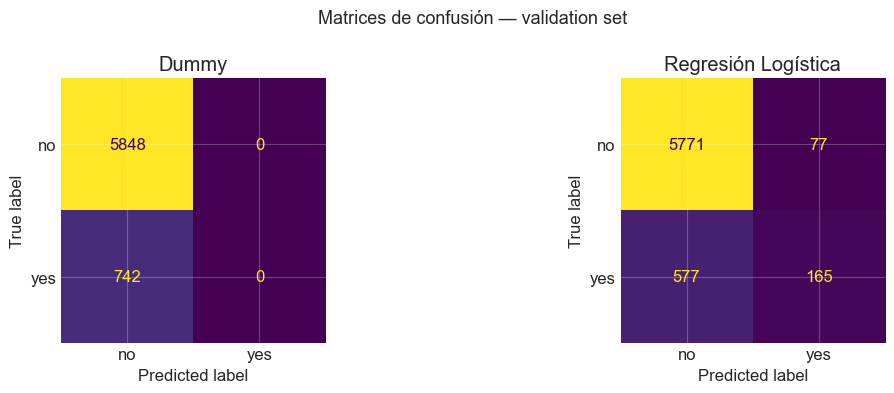

In [29]:
# Comparación y curva ROC
# Tabla comparativa
df_resultados = pd.DataFrame(resultados)
print("\n── COMPARACIÓN DE BASELINES (evaluados en validation) ──────────────")
display(df_resultados.set_index("modelo").round(4))

# Guardar métricas
df_resultados.to_csv("../report/baseline_metrics.csv", index=False)
print("✅ Métricas guardadas en report/baseline_metrics.csv")

# Curva ROC
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(logreg, X_val, y_val,
                                name="Regresión Logística", ax=ax)
ax.plot([0,1],[0,1], linestyle="--", color="gray", label="Dummy (AUC=0.50)")
ax.set_title("Curva ROC — Baseline vs Dummy (validation set)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "roc_baseline.png", dpi=150)
plt.show()

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nombre, modelo) in zip(axes, [
    ("Dummy",               dummy),
    ("Regresión Logística", logreg),
]):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_val, y_val,
        display_labels=["no", "yes"],
        colorbar=False, ax=ax
    )
    ax.set_title(nombre)
fig.suptitle("Matrices de confusión — validation set", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "confusion_baseline.png", dpi=150)
plt.show()

---
## 11. Conclusiones iniciales

### ¿Qué tan difícil parece el problema?

El Dummy classifier obtiene ROC-AUC = 0.50 por definición — es
el piso absoluto. La regresión logística ya supera ese piso con
un preprocesamiento mínimo, lo que confirma que **hay señal
predictiva real en el dataset**.

### ¿Qué aprendimos del EDA?

- El dataset está **desbalanceado** (~11% positivos) — accuracy no sirve.
- Las variables **macroeconómicas** tienen la mayor correlación con el target.
- `duration` es leakage confirmado y queda excluida.
- Los `"unknown"` se mantienen como categoría válida.
- `education` es la única variable con encoding ordinal justificado.

### ¿Qué sigue en la Entrega 2?

- Comparar al menos 2 familias de modelos (árboles, SVM, ensambles).
- Explorar ajuste de threshold dado el costo asimétrico del error.
- Analizar importancia de variables.
- Evaluar si el desbalance requiere técnicas adicionales (SMOTE, class_weight).

> **Recordatorio:** el test set no ha sido tocado en ningún momento
> de esta entrega. Se reserva para la evaluación final imparcial.